In [1]:
using JLD
using CairoMakie

In [2]:
struct Data
    L::Int
    t::Vector{Float64}
    x::Vector{Float64}
end

In [3]:
set_theme!(
    fontsize=28,
    Legend=(labelsize=28,),
    Axis=(
        xgridvisible=false,
        ygridvisible=false,
    )
)

In [4]:
# ==========================================
# Load data (thermal)
# ==========================================

L_list = 6:12

data = Data[]
for L in L_list
    d = load("Ising//thermal_initial_state//averaged_R2_J=1.0_h=0.0_L=$(L).jld")
    t = d["t"]
    x = d["R2"]
    push!(data, Data(L, t, x))
end

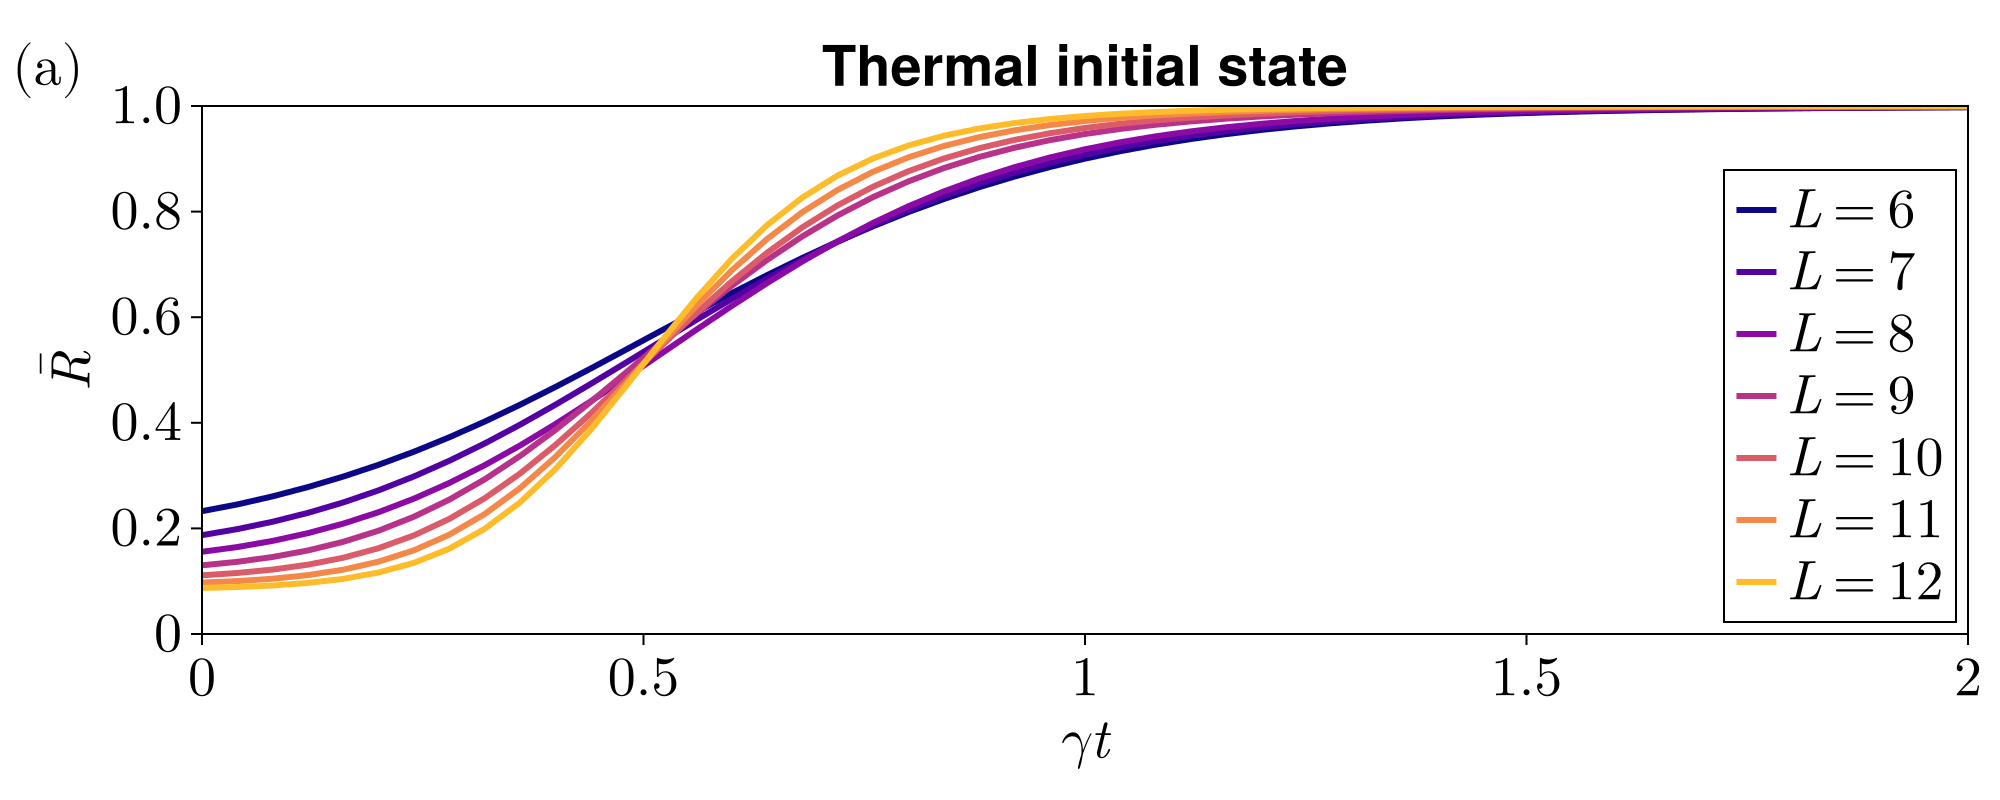

In [5]:
# ==========================================
# Plot raw data (thermal)
# ==========================================

fig = Figure(size=(1000, 400))

ax = Axis(fig[1, 1];
    xticks=(0:0.5:2, [L"0", L"0.5", L"1", L"1.5", L"2"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="Thermal initial state")

xlims!(ax, 0, 2)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(data))] for i in 1:length(data)]

label_list = [L"L = 6", L"L = 7", L"L = 8", L"L = 9", L"L = 10", L"L = 11", L"L = 12"]

for (i, d) in enumerate(data)
    lines!(ax, d.t, d.x, linewidth=3, label=label_list[i], color = color_val[i])
end

axislegend(ax; position=:rb)

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=28,
    halign=:left,
    padding  = (-10, 0, 0, 0))

fig

In [6]:
# ==========================================
# Load data (MBL)
# ==========================================

L_list = 6:12

data = Data[]
for L in L_list
    d = load("Ising//MBL_initial_state//averaged_R2_J=1.0_h=0.0_L=$(L).jld")
    t = d["t"]
    x = d["R2"]
    push!(data, Data(L, t, x))
end

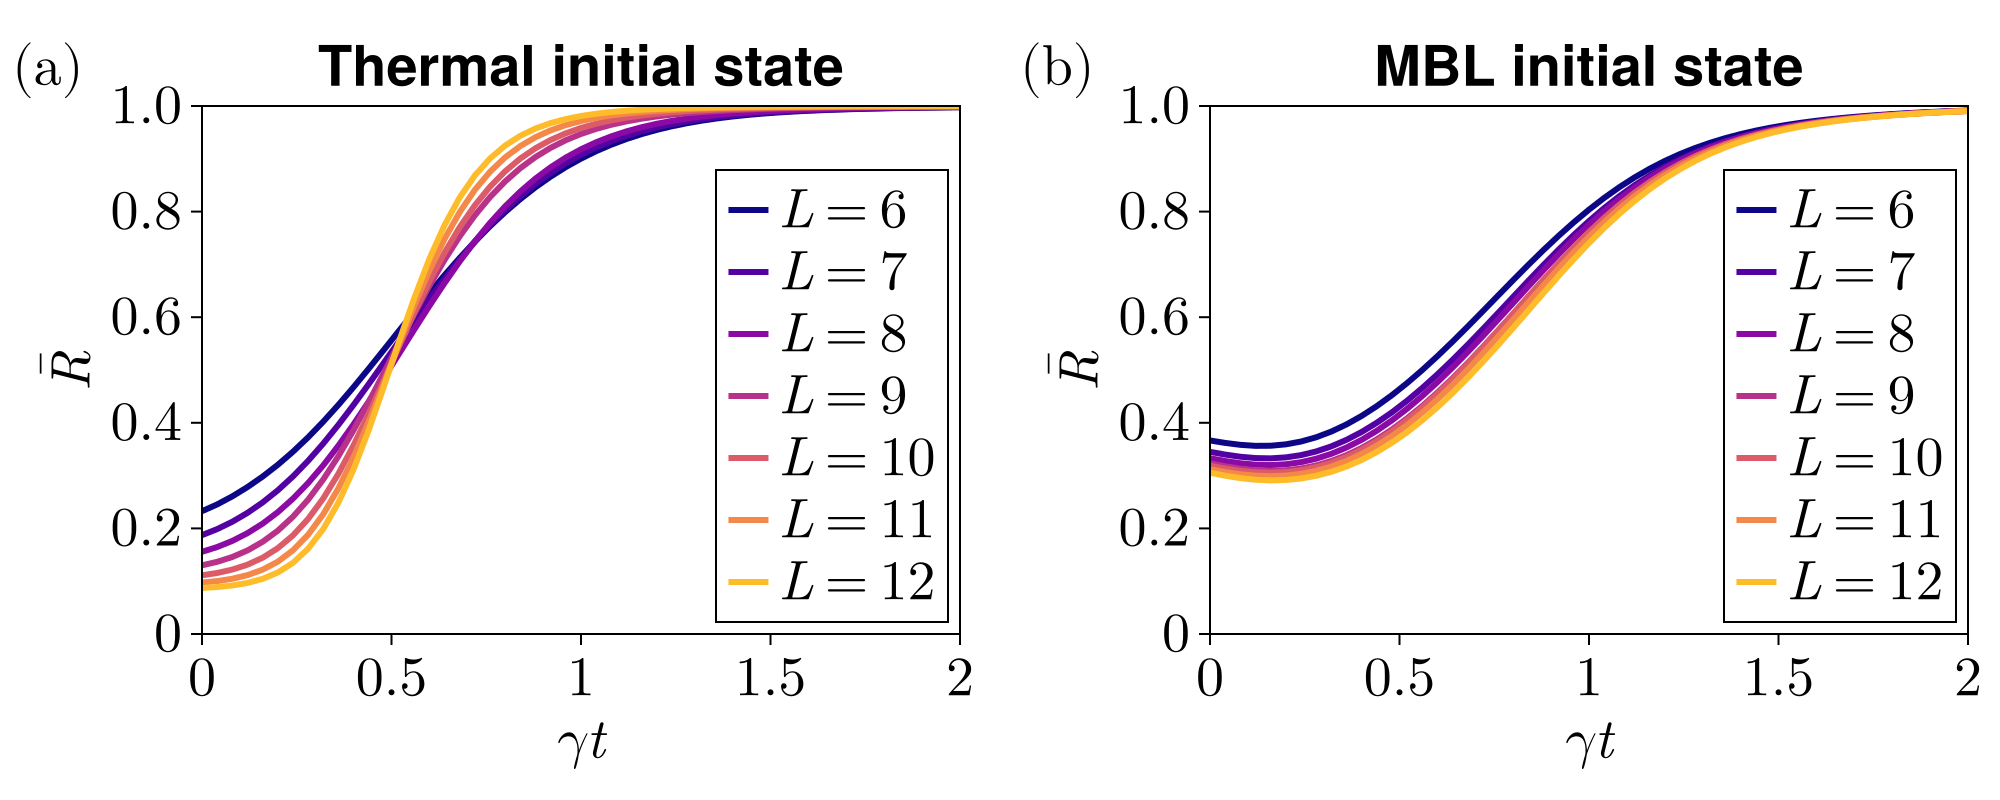

In [7]:
# ==========================================
# Plot raw data (MBL)
# ==========================================

ax = Axis(fig[1, 2];
    xticks=(0:0.5:2, [L"0", L"0.5", L"1", L"1.5", L"2"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="MBL initial state")

xlims!(ax, 0, 2)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(data))] for i in 1:length(data)]

label_list = [L"L = 6", L"L = 7", L"L = 8", L"L = 9", L"L = 10", L"L = 11", L"L = 12"]

for (i, d) in enumerate(data)
    lines!(ax, d.t, d.x, linewidth=3, label=label_list[i], color = color_val[i])
end

axislegend(ax; position=:rb)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=28,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig